[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/firefly1248/demo-notebooks/blob/main/notebooks/uncertainty_attribution_shap.ipynb)

# Attributing prediction uncertainty with SHAP, on data where the answer is known

Prediction intervals vary in width from row to row, and the obvious next question is which features
make a row uncertain. There is no library for that. The common recipe is to take the width as a
target, fit a second model to it, and read that model's SHAP values.

This notebook runs the recipe on data built so the correct answer is known in advance, and puts it
next to three other quantities you can attribute the same way: CatBoost's data and knowledge
uncertainty on their own, and the distance from a row to the nearest training row.

Runtime is under a minute on a laptop CPU and a few minutes on a free Colab runtime.

In [1]:
try:
    import catboost, shap
except ImportError:
    !pip install -q catboost shap

In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.neighbors import NearestNeighbors

## The design

Six features on the unit interval, each with one job.

`x_mean1` and `x_mean2` drive the mean and nothing else. `x_noise` drives the spread, so the noise
grows with it. `x_gap` enters the mean too, but a slice of its range is cut out of the training data
and left in the test data, which makes it the one feature the model is missing information about. `x_dup` is a noisy copy of `x_noise` that enters the target nowhere. `x_inert`
enters nothing at all.

So the honest answer to "where does the uncertainty come from" is `x_noise` for the part that is
irreducible and `x_gap` for the part that more data would fix. `x_dup` is there because SHAP with
correlated features is known to spread credit between them, and this measures how much.

In [3]:
N_TRAIN, N_TEST, N_SEEDS = 8000, 4000, 12
SEEDS = range(N_SEEDS)
GAP = (0.40, 0.60)
Z90 = 1.645
REFERENCE = "true noise function"
FEATURES = ["x_mean1", "x_mean2", "x_noise", "x_dup", "x_gap", "x_inert"]
ROLE = {"x_mean1": "drives the mean", "x_mean2": "drives the mean",
        "x_noise": "drives the spread", "x_dup": "noisy copy of x_noise, enters nothing",
        "x_gap": f"drives the mean, hole at {GAP[0]}-{GAP[1]}",
        "x_inert": "enters nothing"}


def mean_of(x):
    return 10 * np.sin(np.pi * x.x_mean1 * x.x_mean2) + 8 * np.sin(4 * np.pi * x.x_gap)


def sample(n, rng, carve):
    x = pd.DataFrame(rng.uniform(size=(n, len(FEATURES))), columns=FEATURES)
    x["x_dup"] = np.clip(x["x_noise"] + rng.normal(0, 0.05, n), 0, 1)
    if carve:
        x = x[~x["x_gap"].between(*GAP)].reset_index(drop=True)
    sigma = 0.5 + 6 * x.x_noise ** 2
    return x, mean_of(x) + sigma * rng.normal(size=len(x)), sigma


pd.DataFrame([{"feature": f, "role": ROLE[f]} for f in FEATURES])

,feature,role
0,x_mean1,drives the mean
1,x_mean2,drives the mean
2,x_noise,drives the spread
3,x_dup,"noisy copy of x_noise, enters nothing"
4,x_gap,"drives the mean, hole at 0.4-0.6"
5,x_inert,enters nothing


## The recipe

`surrogate` is the whole method: fit a model to the quantity you want explained, then average the
absolute SHAP value of each feature and report it as a share of the total.

In [4]:
def surrogate(X, target, seed):
    m = CatBoostRegressor(iterations=400, learning_rate=0.08, depth=6, random_seed=seed,
                          verbose=0, allow_writing_files=False).fit(X, target)
    v = np.abs(shap.TreeExplainer(m).shap_values(X)).mean(axis=0)
    return pd.Series(100 * v / v.sum(), index=X.columns)

## The run

One `RMSEWithUncertainty` model per seed. `virtual_ensembles_predict` returns the mean, the
knowledge variance and the data variance; both are variances, so they are square-rooted before use,
and the interval width is `2 * Z90 * sqrt(knowledge + data)` with `Z90 = 1.645`, the two-sided 90%
normal quantile.

Five quantities get attributed per seed. The true noise function is included as a reference: it is
the one target whose correct attribution is not in dispute.

The same loop records how the model behaves inside the hole against outside it, which is what makes
`x_gap` worth finding at all.

In [5]:
attr_rows, gap_rows = [], []
for s in SEEDS:
    rng = np.random.default_rng(s)
    Xtr, ytr, _ = sample(N_TRAIN, rng, carve=True)
    Xte, _, sigma = sample(N_TEST, rng, carve=False)

    model = CatBoostRegressor(loss_function="RMSEWithUncertainty", posterior_sampling=True,
                              iterations=1000, learning_rate=0.1, depth=6, random_seed=s,
                              verbose=0, allow_writing_files=False).fit(Xtr, ytr)
    out = model.virtual_ensembles_predict(
        Xte, prediction_type="TotalUncertainty", virtual_ensembles_count=10)
    knowledge, data = np.sqrt(out[:, 1]), np.sqrt(out[:, 2])
    width = 2 * Z90 * np.sqrt(out[:, 1] + out[:, 2])
    dist = NearestNeighbors(n_neighbors=1).fit(Xtr).kneighbors(Xte)[0][:, 0]

    # error against the noiseless mean, so the irreducible part does not mask the hole
    error = np.abs(mean_of(Xte).values - out[:, 0])
    inside = Xte.x_gap.between(*GAP).values
    for label, v in (("error vs the noiseless mean", error), ("knowledge uncertainty", knowledge),
                     ("data uncertainty", data), ("distance to training data", dist)):
        gap_rows.append({"quantity": label, "seed": s,
                         "in the hole": v[inside].mean(), "outside": v[~inside].mean()})

    for label, target in ((REFERENCE, sigma.values), ("interval width", width),
                          ("data uncertainty", data), ("knowledge uncertainty", knowledge),
                          ("distance to training data", dist)):
        attr_rows.append({"target": label, "seed": s, **surrogate(Xte, target, s).to_dict()})
    print(f"seed {s} done", flush=True)

attr_df, gap_df = pd.DataFrame(attr_rows), pd.DataFrame(gap_rows)

seed 0 done


seed 1 done


seed 2 done


seed 3 done


seed 4 done


...

seed 7 done


seed 8 done


seed 9 done


seed 10 done


seed 11 done


## Does the hole matter

Before reading any attribution, check that there is something to attribute.

In [6]:
gap = gap_df.groupby("quantity", sort=False)[["in the hole", "outside"]].mean()
gap["ratio"] = gap["in the hole"] / gap["outside"]
per_seed = gap_df["in the hole"] / gap_df["outside"]
gap["ratio sd"] = per_seed.groupby(gap_df["quantity"], sort=False).std()
gap.round(2)

,in the hole,outside,ratio,ratio sd
quantity,,,,
error vs the noiseless mean,5.35,0.73,7.29,1.13
knowledge uncertainty,0.16,0.10,1.57,0.46
data uncertainty,2.82,1.51,1.87,0.36
distance to training data,0.17,0.13,1.27,0.01


The error column is the one that moves: inside the hole the model is several times more wrong than
outside it. None of the three quantities the model or the training set reports comes anywhere near
matching that rise, and the nearest-neighbour distance moves least of all, because five of the six
dimensions are untouched by the hole and they dominate the distance.

What matters for attribution is not the size of that rise but whether the right feature drives it,
which is what the next cell measures.

## What the attribution says

In [7]:
share = attr_df.groupby("target", sort=False)[FEATURES].mean()
print(f"share of total |SHAP|, %, mean over {N_SEEDS} seeds")
print(share.round(1).to_string())
print()
print("standard deviation across seeds:")
print(attr_df.groupby("target", sort=False)[FEATURES].std().round(1).to_string())
print()
print(f"attributing the {REFERENCE}, where the right answer is not in doubt, still sent "
      f"{share.loc[REFERENCE, 'x_dup']:.0f}% of the credit to x_dup, which enters the target "
      f"nowhere")

share of total |SHAP|, %, mean over 12 seeds
                           x_mean1  x_mean2  x_noise  x_dup  x_gap  x_inert
target                                                                     
true noise function            0.1      0.1     73.8   25.7    0.1      0.1
interval width                 7.6      7.5     35.3   13.3   28.8      7.6
data uncertainty               7.6      7.5     35.5   13.1   28.7      7.6
knowledge uncertainty          8.6      9.2     36.2   16.5   21.8      7.7
distance to training data     10.9     11.1      9.7    9.4   48.0     10.9

standard deviation across seeds:
                           x_mean1  x_mean2  x_noise  x_dup  x_gap  x_inert
target                                                                     
true noise function            0.0      0.1      3.6    3.5    0.1      0.1
interval width                 1.1      1.5      6.2    2.6    8.5      0.9
data uncertainty               1.1      1.5      5.9    2.8    8.4      0.9
knowledge

In [8]:
print(f"where x_gap ranked among the six features over {N_SEEDS} seeds, "
      "and which feature took first place:")
for t in [t for t in share.index if t != REFERENCE]:
    sub = attr_df[attr_df.target == t][FEATURES]
    r = sub.rank(axis=1, ascending=False)["x_gap"].value_counts().sort_index()
    first = sub.idxmax(axis=1).value_counts()
    print(f"  {t}")
    print("      x_gap: " + ", ".join(f"rank {int(k)} on {v}" for k, v in r.items()))
    print("      first: " + ", ".join(f"{k} on {v}" for k, v in first.items()))

where x_gap ranked among the six features over 12 seeds, and which feature took first place:
  interval width
      x_gap: rank 1 on 5, rank 2 on 5, rank 3 on 2
      first: x_noise on 7, x_gap on 5
  data uncertainty
      x_gap: rank 1 on 4, rank 2 on 6, rank 3 on 2
      first: x_noise on 8, x_gap on 4
  knowledge uncertainty
      x_gap: rank 1 on 3, rank 2 on 4, rank 3 on 5
      first: x_noise on 9, x_gap on 3
  distance to training data
      x_gap: rank 1 on 12
      first: x_gap on 12


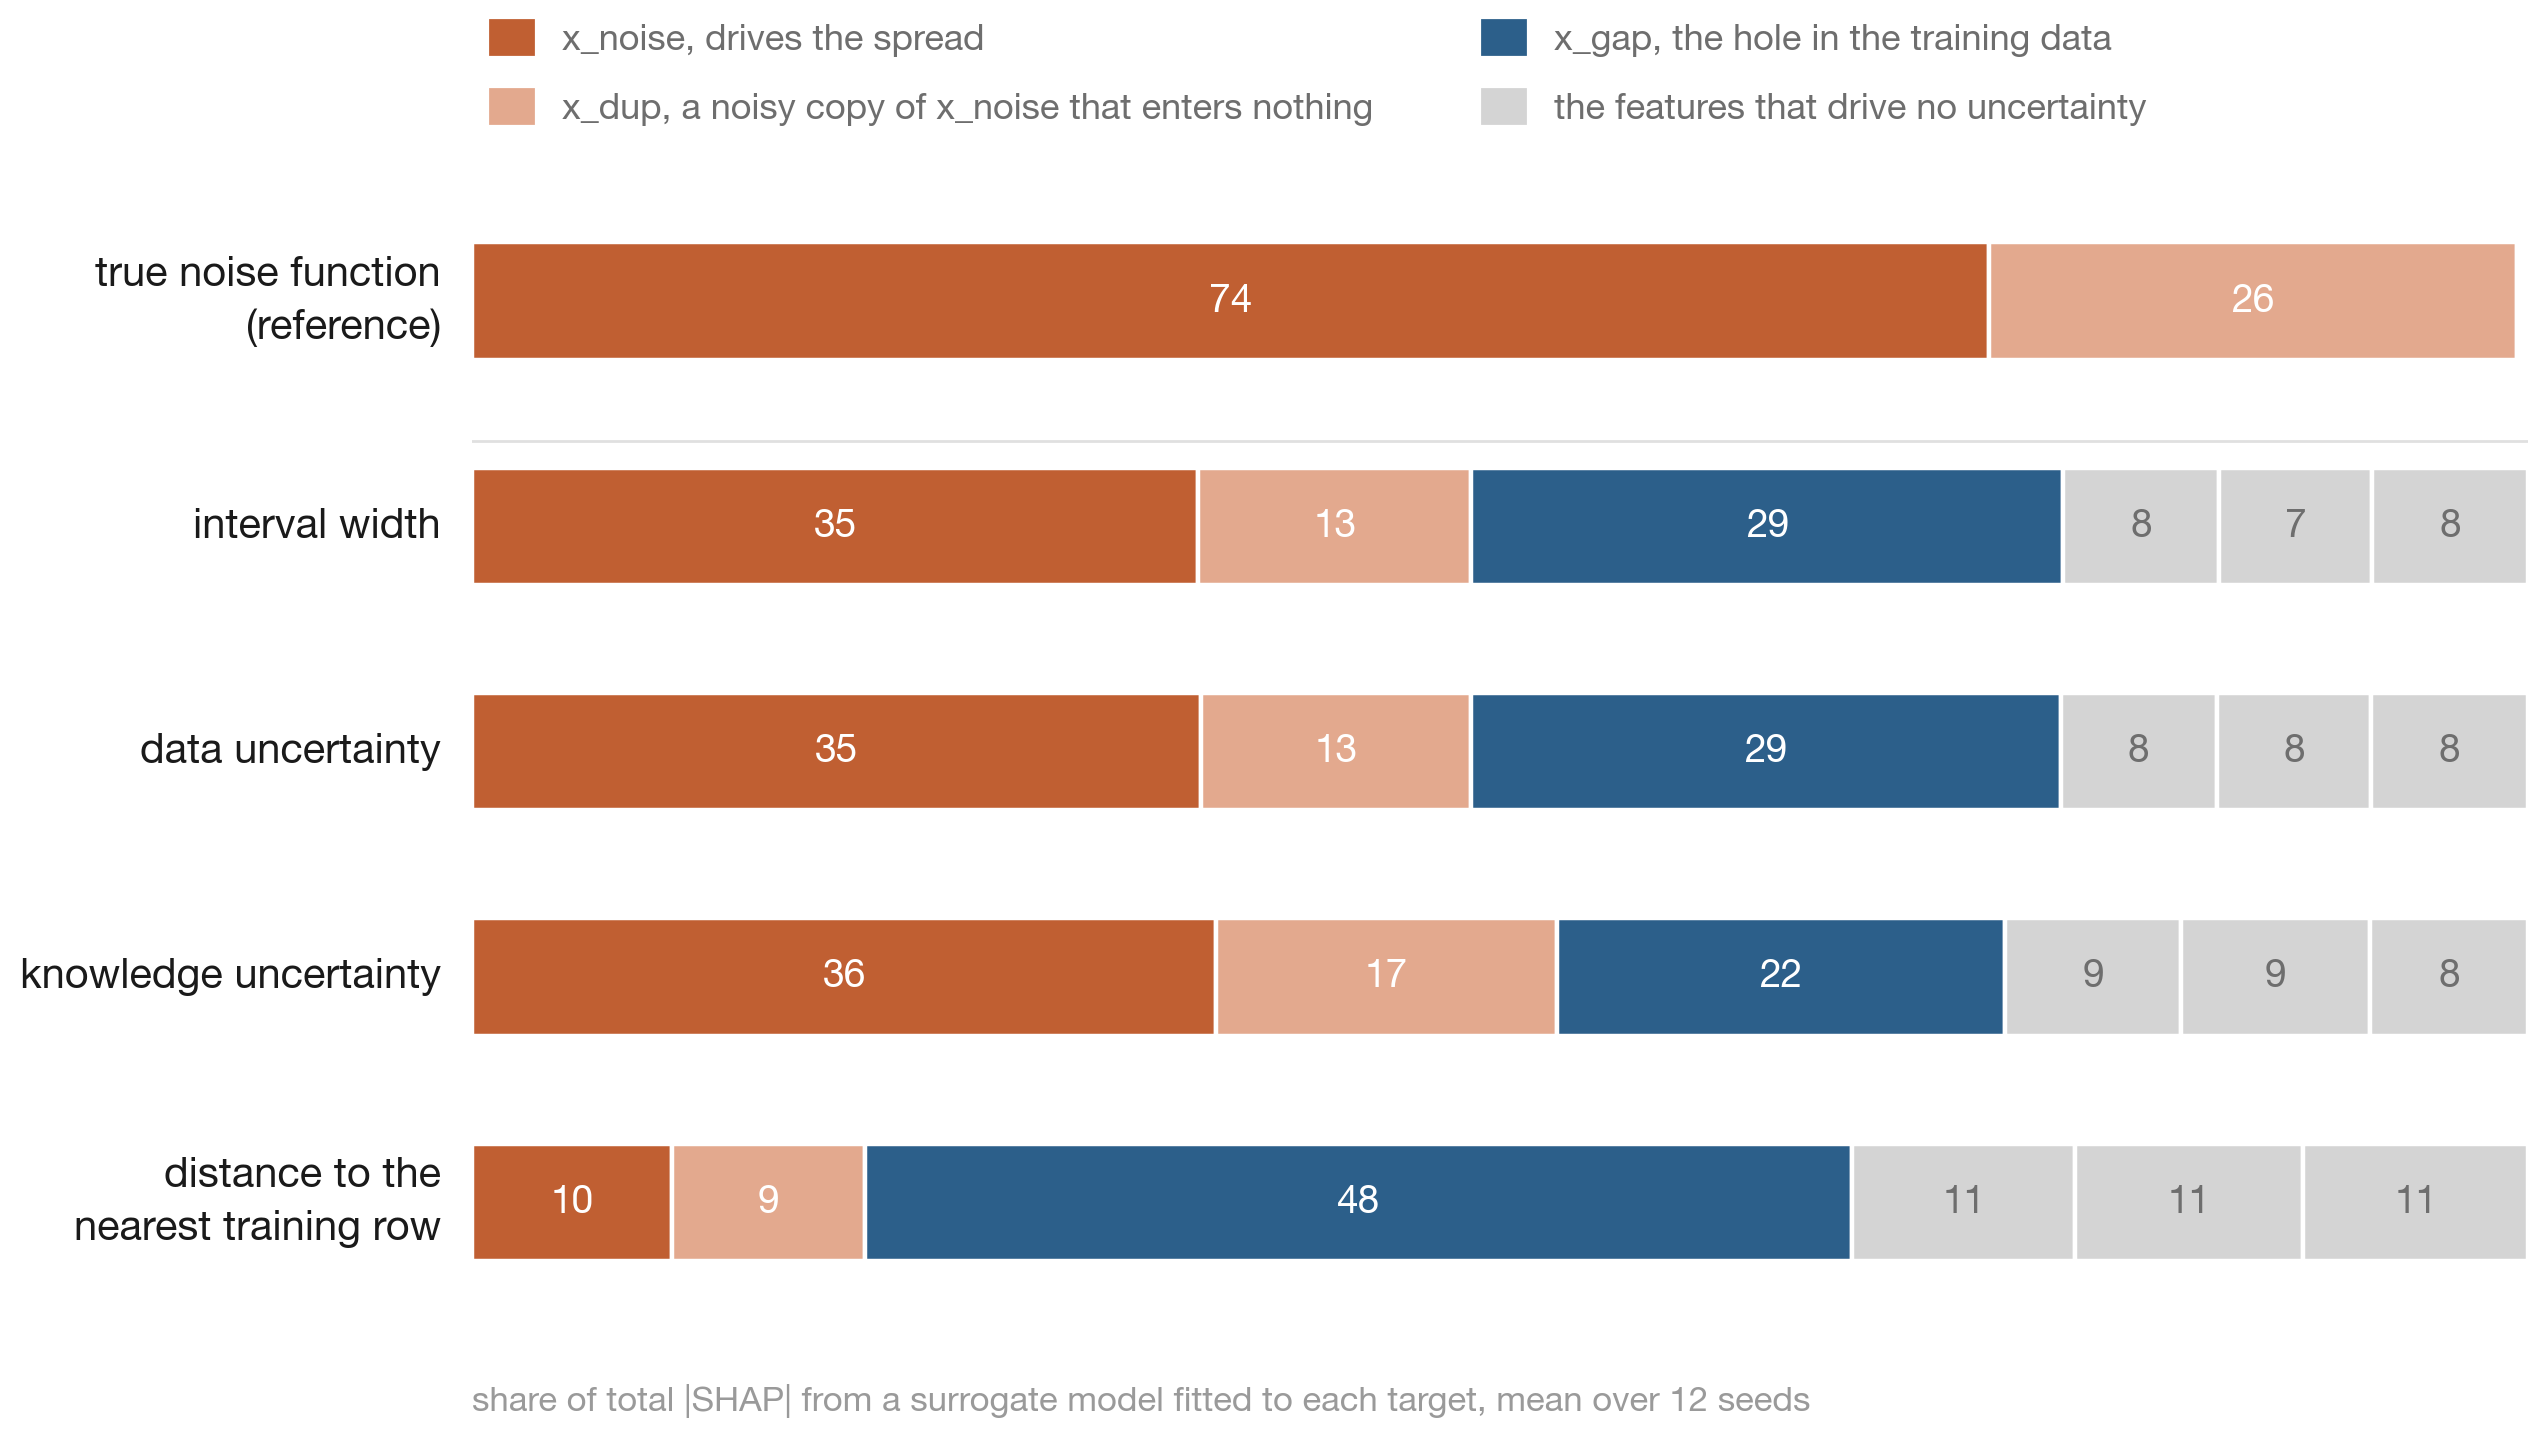

In [9]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"]
BLUE_E, CORAL_E, TWIN_E, GREY_E = "#2C5F8A", "#C05F32", "#E3A98E", "#d4d4d4"
INK, TEXT_MUTED, TEXT_FAINT = "#1a1a1a", "#6e6e6e", "#9a9a9a"

COLOUR = {"x_noise": CORAL_E, "x_dup": TWIN_E, "x_gap": BLUE_E}
PLAIN = [f for f in FEATURES if f not in COLOUR]
ORDER = list(COLOUR) + PLAIN
LEGEND = [(CORAL_E, "x_noise, drives the spread"),
          (TWIN_E, "x_dup, a noisy copy of x_noise that enters nothing"),
          (BLUE_E, "x_gap, the hole in the training data"),
          (GREY_E, "the features that drive no uncertainty")]
LABEL = {REFERENCE: f"{REFERENCE}\n(reference)",
         "distance to training data": "distance to the\nnearest training row"}

fig = plt.figure(figsize=(13.8, 8.6), dpi=200)
ax = fig.add_axes([0.235, 0.095, 0.745, 0.655])
ax.set_xlim(0, 100)
ax.set_ylim(len(share) - 0.5, -0.5)
ax.axis("off")
for i, t in enumerate(share.index):
    left = 0.0
    for f in ORDER:
        w = share.loc[t, f]
        ax.barh(i, w, left=left, height=0.52, color=COLOUR.get(f, GREY_E),
                edgecolor="white", linewidth=1.6, zorder=2)
        if w >= 5:
            ax.text(left + w / 2, i, f"{w:.0f}", ha="center", va="center", fontsize=14,
                    color="white" if f in COLOUR else TEXT_MUTED, zorder=3)
        left += w
    ax.text(-1.5, i, LABEL.get(t, t), ha="right", va="center", fontsize=15, color=INK,
            linespacing=1.5)
ax.axhline(0.62, color="#e0e0e0", lw=1.0)
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c, _ in LEGEND],
          [t for _, t in LEGEND], ncol=2, loc="lower left", bbox_to_anchor=(0, 1.04),
          frameon=False, fontsize=13, labelcolor=TEXT_MUTED, handlelength=1.2,
          handleheight=1.1, columnspacing=3.0, labelspacing=0.9, borderpad=0)
fig.text(0.235, 0.045,
         "share of total |SHAP| from a surrogate model fitted to each target, mean over "
         f"{N_SEEDS} seeds",
         ha="left", va="center", fontsize=12.5, color=TEXT_FAINT)
fig.savefig("uncertainty_attribution_shap.png", facecolor="white")
plt.show()

## Takeaway

Attributing the interval width does rank both real sources above the three features that drive no
uncertainty, and that is the useful part of the answer.

It does not separate the two sources. The interval width row and the data uncertainty row are the
same list to within a fifth of a point, because the data variance dominates the sum under the square
root — so attributing the width is attributing the noise. Reading the knowledge column instead does
not fix that: `x_noise` still leads it, and `x_gap`, the one feature more data would help with, gets
less credit there than the width already gave it. It is also not stable: the rank table above shows
`x_gap` trading places with `x_noise`, and on some seeds falling behind `x_dup`.

The credit given to `x_dup` is the clearest limit. It enters the target nowhere, and attributing
the true noise function, the one case where the correct answer is not in doubt, still hands it a
quarter of the total. That is Shapley with dependent features rather than anything the model did
wrong, and no amount of care in fitting the surrogate removes it.

Distance to the nearest training row answers the narrower question cleanly, because it is a
statement about the training set rather than about the target. If what you need to know is where
more data would help, measure that instead of explaining the width.